# Module 1.7 — 1D Diffusion Equation

The **diffusion equation** describes how quantities spread out over time due to gradients:

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$$

**Physical examples:**
- Heat spreading along a rod ($u$ = temperature, $\alpha$ = thermal diffusivity)
- Ink spreading in still water ($u$ = concentration, $\alpha$ = molecular diffusivity)
- Momentum spreading in a viscous fluid ($u$ = velocity, $\alpha$ = kinematic viscosity $\nu$)

**Key intuition:** $\frac{\partial^2 u}{\partial x^2}$ measures curvature.
- Peaks ($\partial^2 u/\partial x^2 < 0$) → $\partial u/\partial t < 0$ → peak **shrinks**
- Valleys ($\partial^2 u/\partial x^2 > 0$) → $\partial u/\partial t > 0$ → valley **fills up**

Nature flattens curvature — that is diffusion.

## 1. Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded   # for implicit scheme (Section 9)

## 2. Define Domain and Initial Condition

We use a **Gaussian pulse** — a smooth sharp spike — as our initial condition.
This is our "drop of ink" at $x = x_0$ at time $t = 0$.

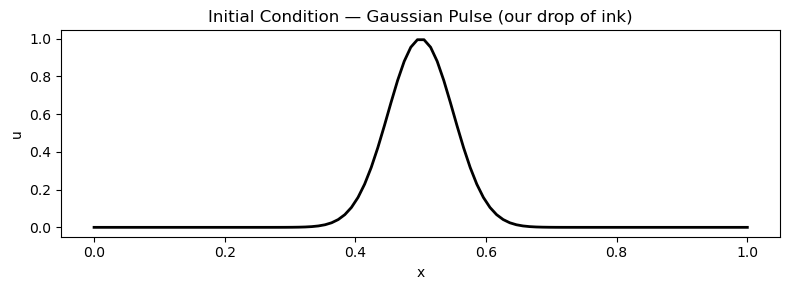

Grid: N = 100,  dx = 0.0101


In [2]:
# ── Spatial domain ────────────────────────────────────────────────────────────
L  = 1.0          # domain length [0, L]
N  = 100          # number of grid points
dx = L / (N - 1)  # grid spacing (N-1 intervals for N points)
x  = np.linspace(0, L, N)

# ── Initial condition: Gaussian pulse centred at x0 ───────────────────────────
x0    = 0.5    # centre of pulse
sigma = 0.05   # width of pulse (small = sharp spike)
u0    = np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))

plt.figure(figsize=(8, 3))
plt.plot(x, u0, "k-", lw=2)
plt.title("Initial Condition — Gaussian Pulse (our drop of ink)", fontsize=12)
plt.xlabel("x"); plt.ylabel("u")
plt.tight_layout(); plt.show()
print(f"Grid: N = {N},  dx = {dx:.4f}")

## 3. Set Diffusion Parameters

The **diffusion number** $r$ controls stability:

$$r = \frac{\alpha \, \Delta t}{\Delta x^2} \leq \frac{1}{2} \quad \text{(stability condition for explicit scheme)}$$

We'll pick $r = 0.4$ (stable) to start.

In [3]:
alpha = 0.01          # diffusion coefficient
r     = 0.4           # diffusion number r = alpha * dt / dx^2  (must be <= 0.5)
dt    = r * dx**2 / alpha
nt    = 200           # number of time steps
T     = nt * dt       # total simulation time

print(f"alpha = {alpha}")
print(f"dx    = {dx:.4f}")
print(f"dt    = {dt:.6f}")
print(f"r     = {r}  (stable: r <= 0.5)")
print(f"Total time T = {T:.4f}")

alpha = 0.01
dx    = 0.0101
dt    = 0.004081
r     = 0.4  (stable: r <= 0.5)
Total time T = 0.8162


## 4. Explicit Scheme — FTCS (Forward Time, Central Space)

Substituting the 2nd-order central difference into the diffusion equation:

$$\frac{u_i^{n+1} - u_i^n}{\Delta t} = \alpha \frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2}$$

Rearranging to solve for $u_i^{n+1}$:

$$\boxed{u_i^{n+1} = u_i^n + r\left(u_{i+1}^n - 2u_i^n + u_{i-1}^n\right)}, \quad r = \frac{\alpha \Delta t}{\Delta x^2}$$

This uses **only current-time values** on the right — fully **explicit**. No linear system to solve.

**Boundary conditions:** We fix $u = 0$ at both walls (Dirichlet BCs) — like a rod clamped at zero temperature at each end.

In [4]:
def solve_explicit(u0, alpha, dx, dt, nt, save_every=40):
    """FTCS explicit scheme for 1D diffusion. Returns list of saved snapshots."""
    u = u0.copy()
    r = alpha * dt / dx**2
    snapshots = [(0, u.copy())]  # (step, solution)

    for n in range(1, nt + 1):
        u_new = u.copy()
        # interior points only: i = 1 ... N-2
        # u_{i+1} - 2*u_i + u_{i-1}  is the 2nd-order central difference
        u_new[1:-1] = u[1:-1] + r * (u[2:] - 2 * u[1:-1] + u[:-2])
        # Dirichlet BCs: u = 0 at both walls
        u_new[0]  = 0.0
        u_new[-1] = 0.0
        u = u_new

        if n % save_every == 0:
            snapshots.append((n, u.copy()))

    return snapshots, r

snapshots_ex, r_used = solve_explicit(u0, alpha, dx, dt, nt)
print(f"Explicit scheme ran with r = {r_used:.3f}  (stable limit = 0.5)")

Explicit scheme ran with r = 0.400  (stable limit = 0.5)


## 5 & 6. Time-Stepping Loop + Visualize Diffusion Over Time

Let's watch the pulse spread — like ink diffusing in still water.

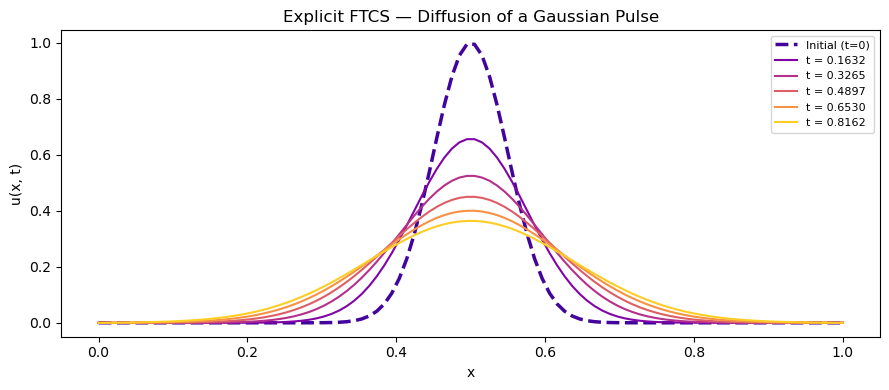

Notice: the pulse flattens and spreads symmetrically — no net movement left or right.
Compare to advection where the pulse MOVED without changing shape!


In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(snapshots_ex)))

for (step, u_snap), color in zip(snapshots_ex, colors):
    label = f"t = {step * dt:.4f}" if step > 0 else "Initial (t=0)"
    lw    = 2.5 if step == 0 else 1.5
    ls    = "--" if step == 0 else "-"
    ax.plot(x, u_snap, color=color, lw=lw, ls=ls, label=label)

ax.set_title("Explicit FTCS — Diffusion of a Gaussian Pulse", fontsize=12)
ax.set_xlabel("x");  ax.set_ylabel("u(x, t)")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

print("Notice: the pulse flattens and spreads symmetrically — no net movement left or right.")
print("Compare to advection where the pulse MOVED without changing shape!")

## 7. Effect of Diffusion Coefficient $\alpha$

Higher $\alpha$ = faster spreading. Lower $\alpha$ = slower, sharper features preserved longer.

Notice we must keep $r = \alpha \Delta t / \Delta x^2 \leq 0.5$, so when $\alpha$ increases we must shrink $\Delta t$.

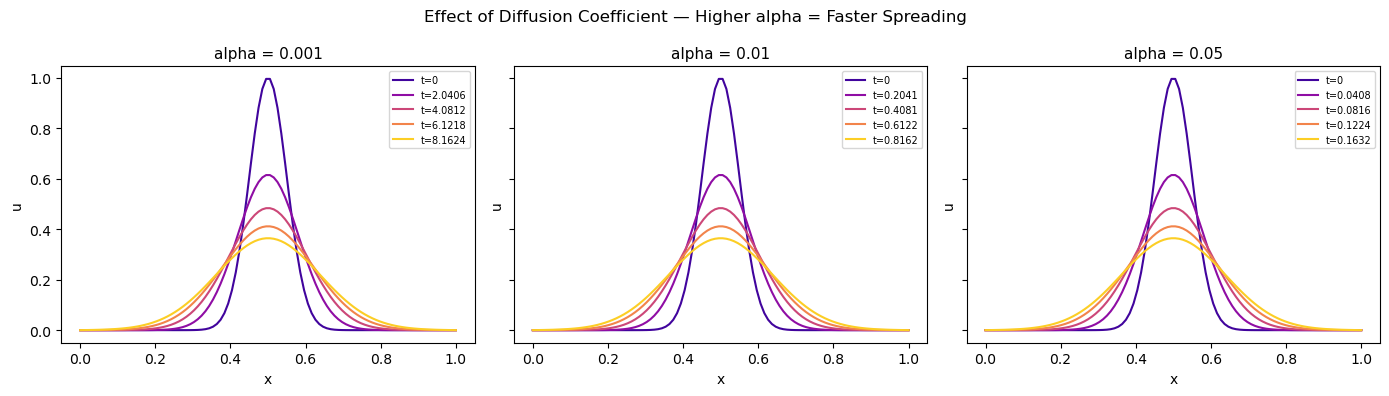

In [6]:
alphas = [0.001, 0.01, 0.05]   # slow → fast diffusion
r_fixed = 0.4                  # keep r constant (stable)
nt_fixed = 200

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, a in zip(axes, alphas):
    dt_a = r_fixed * dx**2 / a
    snaps, _ = solve_explicit(u0, a, dx, dt_a, nt_fixed, save_every=50)
    colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(snaps)))
    for (step, u_snap), color in zip(snaps, colors):
        label = f"t={step*dt_a:.4f}" if step > 0 else "t=0"
        ax.plot(x, u_snap, color=color, lw=1.5, label=label)
    ax.set_title(f"alpha = {a}", fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("u")
    ax.legend(fontsize=7)

plt.suptitle("Effect of Diffusion Coefficient — Higher alpha = Faster Spreading", fontsize=12)
plt.tight_layout(); plt.show()

## 8. Stability Analysis — What Happens When $r > 0.5$?

The stability condition for the explicit FTCS scheme is:

$$r = \frac{\alpha \, \Delta t}{\Delta x^2} \leq \frac{1}{2}$$

**Why?** Von Neumann stability analysis (which we won't derive here) shows that the amplification factor of any Fourier mode becomes $> 1$ when $r > 0.5$, meaning errors grow unboundedly.

Let's *deliberately break* the limit and watch the explosion.

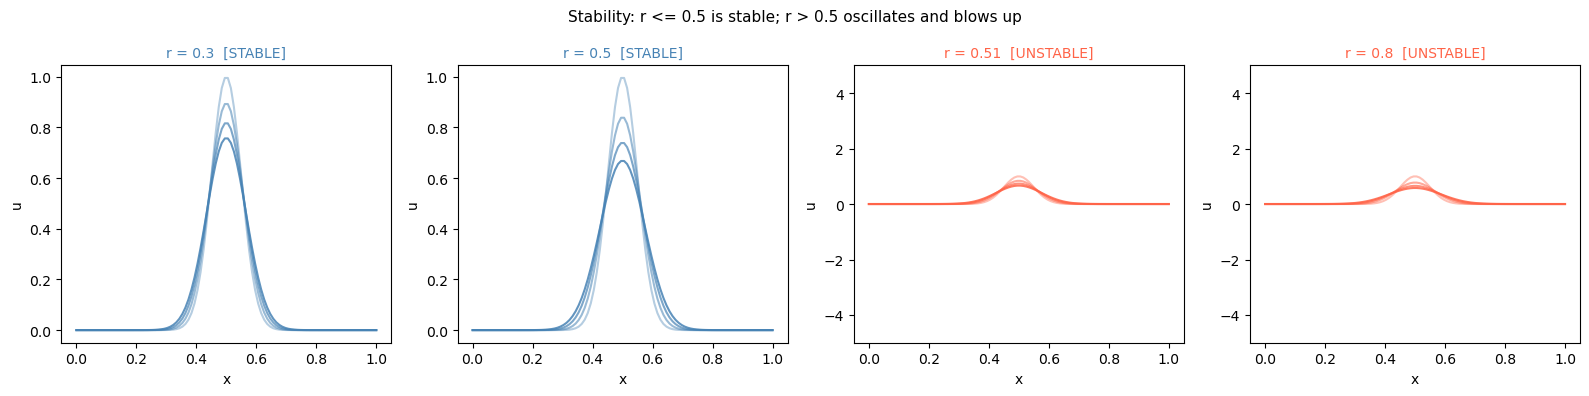

r = 0.51 already shows growing oscillations after just 30 steps!
r = 0.80 explodes violently. This is why the stability condition matters.


In [7]:
r_values = [0.3, 0.5, 0.51, 0.8]   # last two violate the limit
nt_stab  = 30                        # only need a few steps to see blow-up
alpha_s  = 0.01

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

for ax, r_test in zip(axes, r_values):
    dt_test = r_test * dx**2 / alpha_s
    snaps, _ = solve_explicit(u0, alpha_s, dx, dt_test, nt_stab, save_every=10)
    stable = "STABLE" if r_test <= 0.5 else "UNSTABLE"
    color  = "steelblue" if r_test <= 0.5 else "tomato"
    for i, (step, u_snap) in enumerate(snaps):
        ax.plot(x, u_snap, color=color, alpha=0.4 + 0.15 * i, lw=1.5)
    ax.set_title(f"r = {r_test}  [{stable}]", fontsize=10, color=color)
    ax.set_xlabel("x");  ax.set_ylabel("u")
    if r_test > 0.5:
        ax.set_ylim(-5, 5)  # cap axis to show oscillations

plt.suptitle("Stability: r <= 0.5 is stable; r > 0.5 oscillates and blows up", fontsize=11)
plt.tight_layout(); plt.show()

print("r = 0.51 already shows growing oscillations after just 30 steps!")
print("r = 0.80 explodes violently. This is why the stability condition matters.")

## 9. Implicit Scheme — BTCS (Backward Time, Central Space)

Evaluating the diffusion term at the **new** time level $n+1$ instead of $n$:

$$\frac{u_i^{n+1} - u_i^n}{\Delta t} = \alpha \frac{u_{i+1}^{n+1} - 2u_i^{n+1} + u_{i-1}^{n+1}}{\Delta x^2}$$

Rearranging — unknowns at $n+1$ appear on **both sides**:

$$-r\, u_{i-1}^{n+1} + (1 + 2r)\, u_i^{n+1} - r\, u_{i+1}^{n+1} = u_i^n$$

This is a **tridiagonal linear system** $A \mathbf{u}^{n+1} = \mathbf{u}^n$ where:

$$A = \begin{pmatrix} 1+2r & -r & & \\ -r & 1+2r & -r & \\ & \ddots & \ddots & \ddots \\ & & -r & 1+2r \end{pmatrix}$$

We solve this with `scipy.linalg.solve_banded`. Reward: **unconditionally stable** — any $r$ works!

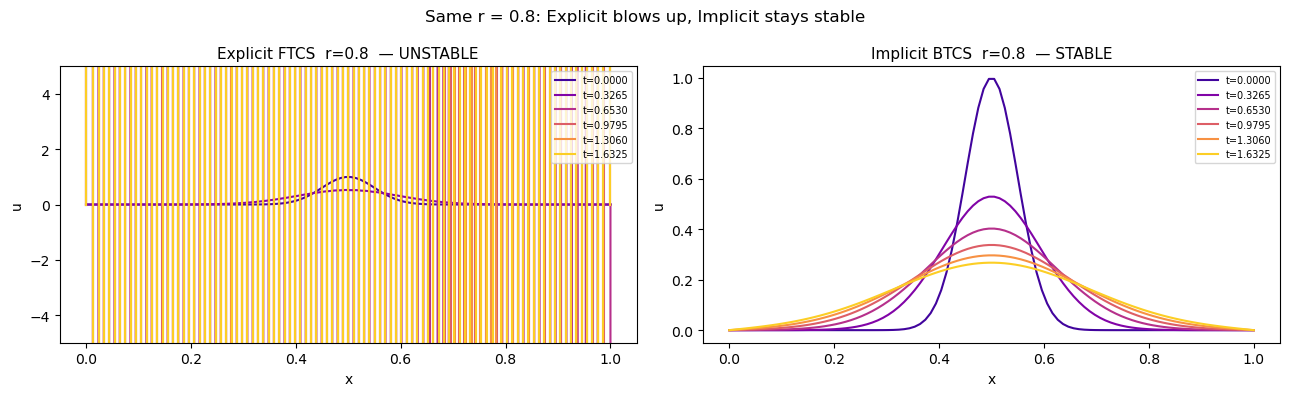

In [8]:
def solve_implicit(u0, alpha, dx, dt, nt, save_every=40):
    """BTCS implicit scheme. Solves tridiagonal system at each step."""
    N = len(u0)
    r = alpha * dt / dx**2
    u = u0.copy()
    snapshots = [(0, u.copy())]

    # Build the tridiagonal matrix A in banded storage (scipy format)
    # ab[0] = superdiagonal, ab[1] = main diagonal, ab[2] = subdiagonal
    ab = np.zeros((3, N))
    ab[0, 1:]  = -r           # superdiagonal (u_{i+1} coefficient)
    ab[1, :]   =  1 + 2 * r   # main diagonal
    ab[2, :-1] = -r           # subdiagonal  (u_{i-1} coefficient)

    # Enforce Dirichlet BCs at boundaries by fixing first and last row
    ab[1, 0]  = 1.0;  ab[0, 1]  = 0.0   # first row: u_0 = 0
    ab[1, -1] = 1.0;  ab[2, -2] = 0.0   # last row:  u_{N-1} = 0

    for n in range(1, nt + 1):
        rhs = u.copy()
        rhs[0] = 0.0    # Dirichlet BC
        rhs[-1] = 0.0   # Dirichlet BC
        u = solve_banded((1, 1), ab, rhs)
        if n % save_every == 0:
            snapshots.append((n, u.copy()))

    return snapshots, r

# ── Compare explicit vs implicit using the SAME large r (r = 0.8) ─────────────
alpha_c = 0.01
r_large = 0.8        # violates the explicit limit!
dt_large = r_large * dx**2 / alpha_c
nt_c = 200

snaps_ex_unstable, _ = solve_explicit(u0, alpha_c, dx, dt_large, nt_c, save_every=40)
snaps_im_stable,   _ = solve_implicit(u0, alpha_c, dx, dt_large, nt_c, save_every=40)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(snaps_im_stable)))

for ax, snaps, title in zip(
    axes,
    [snaps_ex_unstable, snaps_im_stable],
    [f"Explicit FTCS  r={r_large}  — UNSTABLE", f"Implicit BTCS  r={r_large}  — STABLE"]
):
    for (step, u_snap), color in zip(snaps, colors):
        ax.plot(x, u_snap, color=color, lw=1.5, label=f"t={step*dt_large:.4f}")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x");  ax.set_ylabel("u")
    if "Explicit" in title:
        ax.set_ylim(-5, 5)
    ax.legend(fontsize=7)

plt.suptitle(f"Same r = {r_large}: Explicit blows up, Implicit stays stable", fontsize=12)
plt.tight_layout(); plt.show()

## Summary — Explicit vs Implicit

| Property | Explicit (FTCS) | Implicit (BTCS) |
|----------|----------------|-----------------|
| Time level used | $n$ (current) | $n+1$ (future) |
| Solve linear system? | No | Yes (tridiagonal) |
| Stability condition | $r \leq 0.5$ | Unconditionally stable |
| Cost per step | Cheap $O(N)$ | Moderate $O(N)$ (tridiagonal) |
| When to use | Fine grids, small $\alpha$ | Large $\Delta t$, stiff problems |

**Key insight:** The implicit scheme "looks into the future" — it uses $u^{n+1}$ on the right-hand side. This makes the system self-correcting: any mode trying to grow gets damped. That's why it's unconditionally stable.

**In real CFD codes**, implicit schemes dominate for diffusion-dominated problems (viscous flows, heat conduction), while explicit schemes are used for advection-dominated flows where the CFL limit is less restrictive.

---
## Bonus: Curvature Intuition — Why Peaks Decay and Valleys Fill Up

The diffusion equation is driven by curvature:

$$\frac{\partial u}{\partial t} = \alpha \underbrace{\frac{\partial^2 u}{\partial x^2}}_{\text{curvature}}$$

| Shape at a point | $\partial^2 u/\partial x^2$ | $\partial u/\partial t$ | What happens |
|---|---|---|---|
| Peak (convex) | $< 0$ | $< 0$ | $u$ **decreases** — peak shrinks |
| Valley (concave) | $> 0$ | $> 0$ | $u$ **increases** — valley fills up |
| Flat | $= 0$ | $= 0$ | $u$ unchanged |

We'll construct a profile with both a **peak** and a **valley** and watch each one respond differently — yet governed by the same equation.

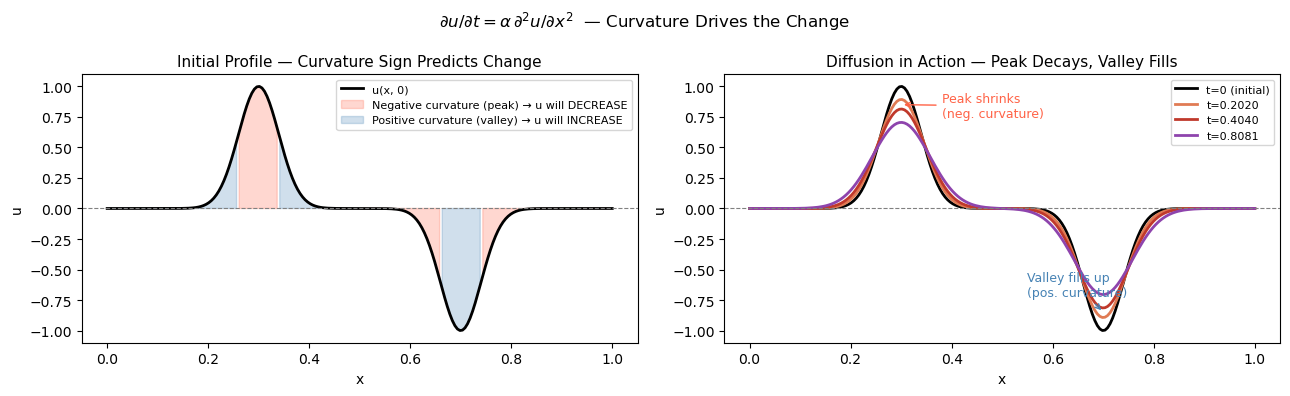

PEAK  at x=0.3: curvature < 0 → du/dt < 0 → amplitude DECREASES over time
VALLEY at x=0.7: curvature > 0 → du/dt > 0 → amplitude INCREASES (fills up)

Both are driven by the SAME diffusion equation — only the sign of curvature differs.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Grid ───────────────────────────────────────────────────────────────────────
L  = 1.0; N = 200; dx = L / (N - 1)
x  = np.linspace(0, L, N)

# ── Initial condition: one PEAK + one VALLEY ───────────────────────────────────
# Peak at x=0.3  (Gaussian bump above zero)
# Valley at x=0.7 (inverted Gaussian, dips below zero)
peak   =  np.exp(-((x - 0.3)**2) / (2 * 0.04**2))
valley = -np.exp(-((x - 0.7)**2) / (2 * 0.04**2))
u0_cv  = peak + valley

# ── Compute curvature of initial profile (2nd derivative via FD) ───────────────
curv = np.zeros(N)
curv[1:-1] = (u0_cv[2:] - 2*u0_cv[1:-1] + u0_cv[:-2]) / dx**2
# curv is d²u/dx² — positive = valley, negative = peak

# ── Run explicit FTCS for a few steps ─────────────────────────────────────────
alpha = 0.001           # small alpha → slow diffusion, easy to see the effect
r     = 0.4
dt    = r * dx**2 / alpha
nt_short = 80           # just enough to see the initial response

u = u0_cv.copy()
snapshots = [u0_cv.copy()]
save_at   = [20, 40, 80]

for step in range(1, nt_short + 1):
    u_new = u.copy()
    u_new[1:-1] = u[1:-1] + r * (u[2:] - 2*u[1:-1] + u[:-2])
    u_new[0] = u_new[-1] = 0.0
    u = u_new
    if step in save_at:
        snapshots.append(u.copy())

# ── Figure 1: curvature map + initial profile ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(x, u0_cv, "k-", lw=2, label="u(x, 0)")
ax.axhline(0, color="gray", lw=0.8, ls="--")

# shade regions by curvature sign
ax.fill_between(x, u0_cv, where=(curv < 0), alpha=0.25, color="tomato",
                label="Negative curvature (peak) → u will DECREASE")
ax.fill_between(x, u0_cv, where=(curv > 0), alpha=0.25, color="steelblue",
                label="Positive curvature (valley) → u will INCREASE")

ax.set_title("Initial Profile — Curvature Sign Predicts Change", fontsize=11)
ax.set_xlabel("x"); ax.set_ylabel("u")
ax.legend(fontsize=8)

# ── Figure 2: time evolution showing peaks decay and valleys fill ──────────────
ax2 = axes[1]
colors = ["black", "#e07b54", "#c0392b", "#8e44ad"]
labels = ["t=0 (initial)", f"t={20*dt:.4f}", f"t={40*dt:.4f}", f"t={80*dt:.4f}"]

for snap, color, label in zip(snapshots, colors, labels):
    ax2.plot(x, snap, color=color, lw=2, label=label)

ax2.axhline(0, color="gray", lw=0.8, ls="--")
ax2.annotate("Peak shrinks\n(neg. curvature)", xy=(0.3, 0.85), xytext=(0.38, 0.75),
             arrowprops=dict(arrowstyle="->", color="tomato"), fontsize=9, color="tomato")
ax2.annotate("Valley fills up\n(pos. curvature)", xy=(0.7, -0.85), xytext=(0.55, -0.72),
             arrowprops=dict(arrowstyle="->", color="steelblue"), fontsize=9, color="steelblue")

ax2.set_title("Diffusion in Action — Peak Decays, Valley Fills", fontsize=11)
ax2.set_xlabel("x"); ax2.set_ylabel("u")
ax2.legend(fontsize=8)

plt.suptitle(r"$\partial u/\partial t = \alpha\,\partial^2 u/\partial x^2$  — Curvature Drives the Change",
             fontsize=12)
plt.tight_layout()
plt.show()

print("PEAK  at x=0.3: curvature < 0 → du/dt < 0 → amplitude DECREASES over time")
print("VALLEY at x=0.7: curvature > 0 → du/dt > 0 → amplitude INCREASES (fills up)")
print()
print("Both are driven by the SAME diffusion equation — only the sign of curvature differs.")